## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import mne
from os.path import join
import nibabel
from matplotlib import colormaps as cmaps
import matplotlib.pyplot as plt
from preprocessing_utils import select_channels
import pickle
import matplotlib.image as mpimg
import os

from viz_utils import mask_distance, place_surface, color_array, brainscatter_static, create_collection_gif, brainscatter_rotation

## Scatter Plot

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


original_viridis = plt.cm.get_cmap('viridis')
original_jet = plt.cm.get_cmap('jet')

def truncated_viridis(x):
    return original_viridis(x * 0.7)

def truncated_jet(x):
    return original_jet(x * 0.7 + 0.2)

class CallableColormap:
    def __init__(self, cmap):
        self.cmap = cmap

    def __call__(self, value):
        return self.cmap(value)

trunc_viridis = CallableColormap(truncated_viridis)
trunc_jet = CallableColormap(truncated_jet)

C:\Users\D-CAP\AppData\Local\Temp\ipykernel_1720\3131441766.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  original_viridis = plt.cm.get_cmap('viridis')
C:\Users\D-CAP\AppData\Local\Temp\ipykernel_1720\3131441766.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  original_jet = plt.cm.get_cmap('jet')


c:\Users\D-CAP\Documents\GitHub\witching-star\viz_utils.py:211: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


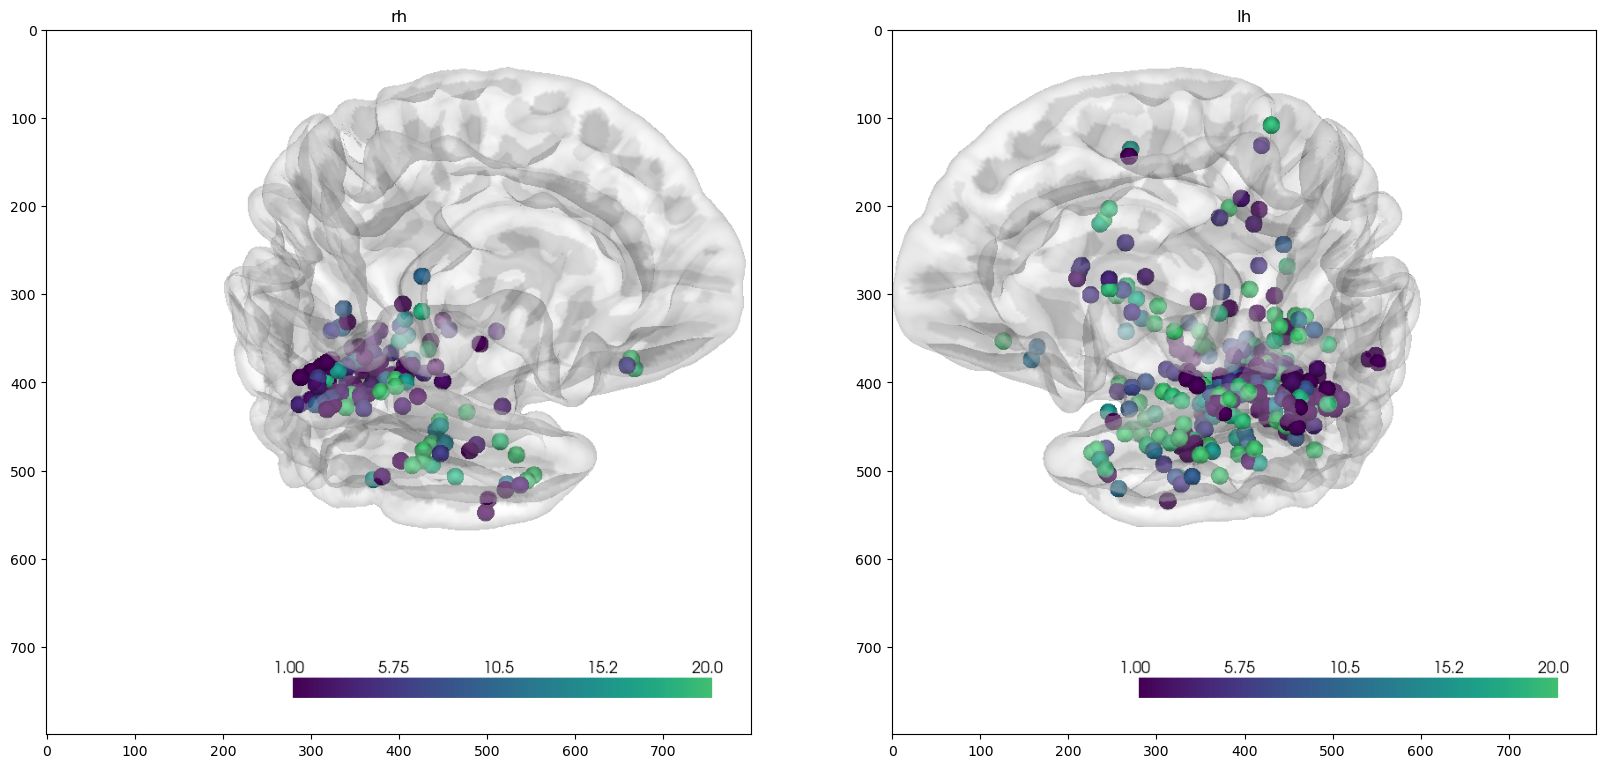

In [ ]:
from matplotlib import cm

left_viewpoint = [(-280, 240, 20),
            (-35, -30, 0),
            (0.5, 1, 2)]

right_viewpoint = [(280, 240, 20),
                (35, -30, 0),
                (-0.5, 1, 2)]


brainplot_file = 'brainplotting/clusters' + '.pickle'
brainplot_file = 'brainplotting/clusters_searchlight.pickle'
file_save = 'D:/BrainPlot/' + 'NMF_' + '/' + str(regressor) 

with open(brainplot_file, 'rb') as file:
    data = pickle.load(file)

scores = np.asarray(data['val'])
locations = np.asarray(data['loc'])
channels = np.asarray(data['name'])


fig, axes = brainscatter_static(scores, locations, channels,
                    min_scores = -1, dist_max = 10, dist_proj = 0, size_points = 20 , alpha = 0.3, #size_points = 20, 15, 13
                    left_viewpoint = left_viewpoint, right_viewpoint = right_viewpoint, hems = ['rh','lh','all'], cmap = cm.bwr,
                    cortex_color = [[0.9,0.9,0.9],'grey'], #'brg', trunc_viridis, ['rh','lh', 'all'] cm.bwr
                    surf_path = 'D:/DataSEEG_Sorciere/BIDS/freesurfer', path_save = file_save,
                    close = False)
